遗传算法入门，解决两个函数的最大值问题
1.一元函数优化f(x)=sin(10pix)/x     x=[1,2]
2.多元函数优化f(x,y) = xcos(2piy) + ysin(2pix)    x,y=[-2,2]

In [1]:
# 生成种群(Nind*Lind)
# Nind是个体数量
# Lind是个体长度
import numpy as np
def create_group(Nind, Lind):
    Chrom = np.random.randint(0, 2, (Nind,Lind), dtype=np.int32)
    return Chrom 

In [2]:
# 二进制转十进制
def bin2dec(Chrom):
    w = np.logspace(Chrom.shape[1]-1, 0, Chrom.shape[1], base=2, dtype=np.int32).reshape(-1,1)
    return np.dot(Chrom,w)

In [3]:
# 针对一元函数的适应度函数
# 根据二进制转十进制得到每个个体所对应的值
def get_true_value(Chrom, low_range, high_range):
    low = low_range * np.ones((Chrom.shape[0],1))
    x = low + bin2dec(Chrom)*(high_range-low_range)/2**Chrom.shape[1]
    return np.sin(10 * np.pi * x) / x, x

In [4]:
# 用锦标赛方式选择优良父代
# 输入：父代种群，该种群对应的价值，每轮锦标赛选择n个父代
# 输出：被选出的父代种群
import random

def select_champion(Chrom, value, candidate):
    ranges = len(value)                                                    # 得到输入种群大小
    selected_father = np.empty((0, Chrom.shape[1]))                        # 创建优良父代合集，暂时为空
    for i in range(0, int(ranges/2)):                                      # 选择int(ranges/2)个父代
        select_pos = np.array(random.sample(range(ranges), candidate))     # 开始选择父代编号
        values = value[select_pos,0]
        max_idx = np.argmax(values)
        max_father = Chrom[select_pos[max_idx], :]                         # 得到一轮锦标赛中的最大个体
        selected_father = np.vstack((selected_father, max_father))
    return selected_father

In [ ]:
# 交叉
# 输入：优良的父代种群，交叉概率
# 输出：交叉后的子代种群
def cross(Chrom, cross_rate):
  crossed_Chrom = Chrom.copy()
  Nind, Lind = Chrom.shape
  # 以 cross_rate 的概率选择参与交叉的个体（按行）
  mask = np.random.rand(Nind) < cross_rate          # 用随机生成的01之间的数与交叉概率相比，小于取1，大于取0
  idx = np.where(mask)[0]                           # 得到需要参与交叉的个体编号
  np.random.shuffle(idx)                            # 随机打乱并两两配对；若为奇数则最后一个保持不变
  for i in range(0, len(idx)-1, 2):
      a = idx[i]
      b = idx[i+1]
      # 随机单点交叉（切点在1..Lind-1之间）
      point = np.random.randint(1, Lind)
      ta = crossed_Chrom[a, point:].copy()
      crossed_Chrom[a, point:] = crossed_Chrom[b, point:]
      crossed_Chrom[b, point:] = ta
  return crossed_Chrom

In [6]:
# 变异操作
# 输入：交叉操作后的种群，变异率
# 输出：变异后的子代种群
def variation(Chrom, variation_rate):
    mutated_Chrom = Chrom.copy()
    Nind, Lind = Chrom.shape
    # 以 variation_rate 的概率选择参与变异的个体（按行）
    mask = np.random.rand(Nind) < variation_rate
    idx = np.where(mask)[0]
    for i in idx:
        # 随机选择变异位置
        point = np.random.randint(0, Lind)
        # 变异操作：将该位置的基因取反
        mutated_Chrom[i, point] = 1 - mutated_Chrom[i, point]
    return mutated_Chrom

In [7]:
# 更新种群
# 输入：原始种群，子代种群
# 输出：更新后的种群
def update_population(Chrom, new_Chrom, low_range, high_range, elitism=True):
    # Chrom: 原始种群 (Nind, Lind)
    # new_Chrom: 子代种群 (可以与 Chrom 同大小或不同)
    # 合并父代和子代，然后选择适应度最高的 Nind 个个体作为新种群
    Nind = Chrom.shape[0]
    combined = np.vstack((Chrom, new_Chrom))
    # 计算合并种群的适应度值
    values, x = get_true_value(combined, low_range, high_range)
    # 按适应度值从大到小排序，选择前 Nind 个个体
    sorted_indices = np.argsort(values[:, 0])[::-1]  # 从大到小排序
    combined = combined[sorted_indices, :]  # 按适应度值排序后的
    new_pop = combined[:Nind, :]
    return new_pop

In [8]:
# 计算种群中的最优个体
def get_best_individual(Chrom, low_range, high_range):
    values, x = get_true_value(Chrom, low_range, high_range)
    best_idx = np.argmax(values[:, 0])
    return values[best_idx, 0], x[best_idx, 0]

In [9]:
# 开始计算
Nind, Lind = 100, 20
Maxgen = 40
cross_rate = 0.7
variation_rate = 0.1
result = np.zeros((Maxgen,2), dtype=np.float32)  # 用于存储每代的最优值
# 生成种群(Nind*Lind)
Chrom = create_group(Nind, Lind)

# 用于存储所有代数的数据（用于绘图）
all_generations = []
all_best_values = []
all_best_x = []

for gen in range(Maxgen):
    # 计算适应度
    value, x = get_true_value(Chrom, 1, 2)
    # 选择父代
    selected_father = select_champion(Chrom, value, 3)
    # 交叉
    crossed_Chrom = cross(selected_father, cross_rate)
    # 变异
    mutated_Chrom = variation(crossed_Chrom, variation_rate)
    # 更新种群
    Chrom = update_population(Chrom, mutated_Chrom, 1, 2)
    # 输出当前代数和最优个体
    best_individual, x = get_best_individual(Chrom, 1, 2)
    result[gen,:] = [best_individual, x]
    all_generations.append(gen + 1)
    all_best_values.append(best_individual)
    all_best_x.append(x)
    print(f"Generation {gen+1}: Best Individual = {best_individual}:Best x {x}")
    # 如果数据已经连续5代没有优化，则取中断循环
    if gen > 4 and np.argmax(result[:,0]) < gen - 4:
        print("No improvement in the last 5 generations, stopping early.")
        break
# 输出最终结果
best_value, best_x = result[np.argmax(result[:,0]), :]
print(f"Best Individual = {best_value}:Best x {best_x}")

Generation 1: Best Individual = 0.9525325015360583:Best x 1.0482540130615234
Generation 2: Best Individual = 0.9525325015360583:Best x 1.0482540130615234
Generation 3: Best Individual = 0.9525325015360583:Best x 1.0482540130615234
Generation 4: Best Individual = 0.9525325015360583:Best x 1.0482540130615234
Generation 5: Best Individual = 0.9525864221297075:Best x 1.0483312606811523
Generation 6: Best Individual = 0.9525864221297075:Best x 1.0483312606811523
Generation 7: Best Individual = 0.9525864221297075:Best x 1.0483312606811523
Generation 8: Best Individual = 0.9525864221297075:Best x 1.0483312606811523
Generation 9: Best Individual = 0.9525864221297075:Best x 1.0483312606811523
Generation 10: Best Individual = 0.9525914427964973:Best x 1.0483388900756836
Generation 11: Best Individual = 0.9525914427964973:Best x 1.0483388900756836
Generation 12: Best Individual = 0.9525914427964973:Best x 1.0483388900756836
Generation 13: Best Individual = 0.9525914427964973:Best x 1.048338890075

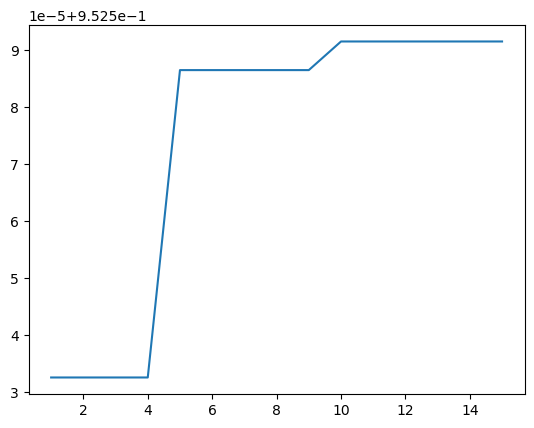

In [10]:
# 绘图
import matplotlib.pyplot as plt

plt.plot(all_generations, all_best_values)
plt.show()

可以看到，因为采用了精英优化，优化的值是单调不减的。且所求的值趋近于极值

接下来讨论多元函数优化f(x,y) = xcos(2piy) + ysin(2pix)    x,y=[-2,2]

对数据的转换：令x，y都化为20维的数据，则总数据为40维，计算适应度时分开，而交叉变异时合在一起

In [11]:
def seperate(Chrom):
    # 将Chrom分为x和y两部分
    Lind = Chrom.shape[1]
    x_Crome = Chrom[:, :Lind//2]
    y_Crome = Chrom[:, Lind//2:]
    return x_Crome, y_Crome

In [ ]:
# get_true_value在二元函数时的变体
def get_true_value_2(Chrom, low_range_x, high_range_x, low_range_y, high_range_y):
    low_x = low_range_x * np.ones((Chrom.shape[0],1))
    low_y = low_range_y * np.ones((Chrom.shape[0],1))
    Chrom_x, Chrom_y = seperate(Chrom)
    x = low_x + bin2dec(Chrom_x)*(high_range_x - low_range_x)/2**Chrom_x.shape[1]
    y = low_y + bin2dec(Chrom_y)*(high_range_y - low_range_y)/2**Chrom_y.shape[1]
    return x*(np.cos(2*np.pi*y)) + y*(np.cos(2*np.pi*x)), x, y

In [ ]:
# update_population在二元函数时的变体
def update_population_2(Chrom, new_Chrom, low_range_x, high_range_x, low_range_y, high_range_y):
    # Chrom: 原始种群 (Nind, Lind)
    # new_Chrom: 子代种群 (可以与 Chrom 同大小或不同)
    # 合并父代和子代，然后选择适应度最高的 Nind 个个体作为新种群
    Nind = Chrom.shape[0]
    combined = np.vstack((Chrom, new_Chrom))
    # 计算合并种群的适应度值
    values, x, y = get_true_value_2(combined, low_range_x, high_range_x, low_range_y, high_range_y)
    # 按适应度值从大到小排序，选择前 Nind 个个体
    sorted_indices = np.argsort(values[:, 0])[::-1]  # 从大到小排序
    combined = combined[sorted_indices, :]  # 按适应度值排序后的
    new_pop = combined[:Nind, :]
    return new_pop

In [ ]:
# get_best_individual在二元函数时的变体
# 计算种群中的最优个体
def get_best_individual_2(Chrom, low_range_x, high_range_x, low_range_y, high_range_y):
    values, x, y = get_true_value_2(Chrom, low_range_x, high_range_x, low_range_y, high_range_y)
    best_idx = np.argmax(values[:, 0])
    return values[best_idx, 0], x[best_idx, 0], y[best_idx, 0]

In [ ]:
# 开始计算
Nind, Lind = 100, 40
Maxgen = 400
cross_rate = 0.8
variation_rate = 0.1        # 该二元函数极值点较多，容易陷入局部最优，变异率可适当加大
result = np.zeros((Maxgen,3), dtype=np.float32)  # 用于存储每代的最优值
# 生成种群(Nind*Lind)
Chrom = create_group(Nind, Lind)

# 用于存储所有代数的数据（用于绘图）
all_generations = []
all_best_values = []
all_best_x = []
all_best_y = []

for gen in range(Maxgen):
    # 计算适应度
    value, x, y = get_true_value_2(Chrom, -2, 2, -2, 2)
    # 选择父代
    selected_father = select_champion(Chrom, value, 3)
    # 交叉
    crossed_Chrom = cross(selected_father, cross_rate)
    # 变异
    mutated_Chrom = variation(crossed_Chrom, variation_rate)
    # 更新种群
    Chrom = update_population_2(Chrom, mutated_Chrom, -2, 2, -2, 2)
    # 输出当前代数和最优个体
    best_individual, x, y = get_best_individual_2(Chrom, -2, 2, -2, 2)
    result[gen,:] = [best_individual, x, y]
    all_generations.append(gen + 1)
    all_best_values.append(best_individual)
    all_best_x.append(x)
    all_best_y.append(y)
    print(f"Generation {gen+1}: Best Individual = {best_individual}:Best x {x}:Best y {y}")
    # 如果数据已经连续5代没有优化，则取中断循环
    if gen > 4 and np.argmax(result[:,0]) < gen - 10:
        print("No improvement in the last 5 generations, stopping early.")
        break
# 输出最终结果
best_value, best_x, best_y = result[np.argmax(result[:,0]), :]
print(f"Best Individual = {best_value}:Best x {best_x}:Best y {best_y}")

Generation 1: Best Individual = 3.0109232912047306:Best x -1.8845977783203125:Best y 1.5116767883300781
Generation 2: Best Individual = 3.0109232912047306:Best x -1.8845977783203125:Best y 1.5116767883300781
Generation 3: Best Individual = 3.0109232912047306:Best x -1.8845977783203125:Best y 1.5116767883300781
Generation 4: Best Individual = 3.8295834828014104:Best x 1.9508743286132812:Best y 1.9832420349121094
Generation 5: Best Individual = 3.8295834828014104:Best x 1.9508743286132812:Best y 1.9832420349121094
Generation 6: Best Individual = 3.8295834828014104:Best x 1.9508743286132812:Best y 1.9832420349121094
Generation 7: Best Individual = 3.8536979192831957:Best x 1.9508743286132812:Best y 1.9974708557128906
Generation 8: Best Individual = 3.9418928281828354:Best x 1.9821243286132812:Best y 1.9832420349121094
Generation 9: Best Individual = 3.9418928281828354:Best x 1.9821243286132812:Best y 1.9832420349121094
Generation 10: Best Individual = 3.9418928281828354:Best x 1.982124328

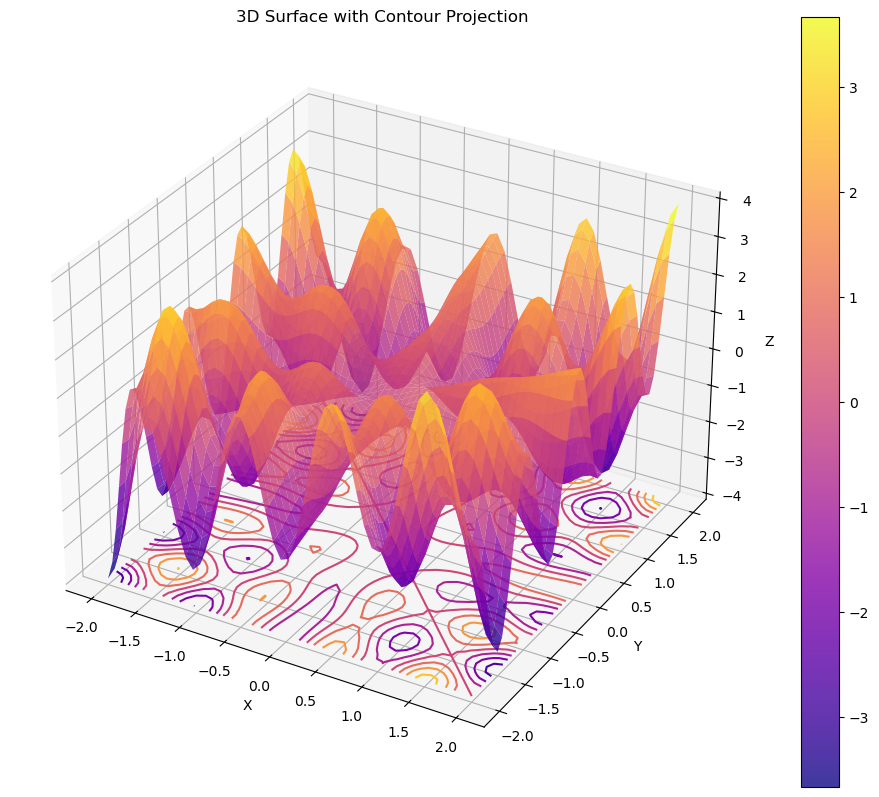

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 定义二元函数
def f(x, y):
    return x*(np.cos(2*np.pi*y)) + y*(np.cos(2*np.pi*x))

# 创建数据
x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# 绘制带等高线的3D图
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 曲面
surf = ax.plot_surface(X, Y, Z, cmap='plasma', alpha=0.8)

# 在底部添加等高线投影
ax.contour(X, Y, Z, zdir='z', offset=Z.min(), cmap='plasma')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Surface with Contour Projection')

fig.colorbar(surf)
plt.show()